# AQSM Watermark Extraction Walkthrough

This notebook extracts the watermark from a watermarked carrier image produced by the AQSM/HDWM embedding implementation.

Scope and paper-faithfulness notes:

- This notebook implements the paper's concrete `r = 1` extraction path.
- The paper explicitly says that for `r = 1`, three AQSM watermarks are extracted sequentially from the first three carrier LSB planes.
- The paper then applies inverse QBA, quantum refining, and bit-plane reconstruction.
- This is a classical matrix simulation of the paper's basis-state logic, matching the paper's MATLAB-style simulation setup. It is not a full quantum hardware or statevector simulation.
- No general `r > 1` extraction schedule is invented here.

The watermarked image is loaded from disk as `example_outputs/final_watermarked_output.png`. If that file is missing or stale, this notebook regenerates it from the same USC-SIPI sample pair used by the embedding notebook, then loads the saved PNG back as the extraction input.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from aqsm_embedding import (
    EmbeddingPipeline,
    HDWMExtractor,
    HistogramAnalyzer,
    ImageFileLoader,
    NEQREncoder,
    ScaleParameterCalculator,
    USCSIPISampleDataset,
)

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"


In [2]:
def show_image(image, title, binary=False, size=5):
    plt.figure(figsize=(size, size))
    vmax = 1 if binary else 255
    plt.imshow(image, cmap="gray", vmin=0, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_grid(images, title, binary=False, columns=4, size=3):
    count = len(images)
    rows = (count + columns - 1) // columns
    plt.figure(figsize=(columns * size, rows * size))
    vmax = 1 if binary else 255
    for index, (name, image) in enumerate(images, start=1):
        ax = plt.subplot(rows, columns, index)
        ax.imshow(image, cmap="gray", vmin=0, vmax=vmax)
        ax.set_title(name)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def parameter_table(title, items):
    print(title)
    for key, value in items.items():
        print(f"  {key}: {value}")


## 1. Prepare The Watermarked Output Image

Variables in this section:

- `dataset`: downloader/cache manager for the small USC-SIPI sample set.
- `loader`: image loader/saver that converts files to 8-bit grayscale matrices.
- `original_watermark_image`: the known watermark image used only for parameter reproduction and verification in this notebook.
- `original_carrier_image`: the carrier used to create the watermarked output image.
- `embedding_context`: embedding-side context used to regenerate the watermarked output reproducibly.
- `watermarked_output_path`: the saved watermarked carrier image path.
- `watermarked_image`: the actual extraction input loaded from `watermarked_output_path`.

Clarification: the paper says extraction uses the watermarked image **along with required parameters**. In this demo, we recompute those required parameters from the same sample pair so the notebook is self-contained. In a real watermarking workflow, `tau1`, `tau2`, `r`, and the watermark size must be stored or known as extraction metadata.


Watermarked output loaded from: example_outputs\final_watermarked_output.png
Watermark size: 256 x 256
Watermarked carrier size: 512 x 512


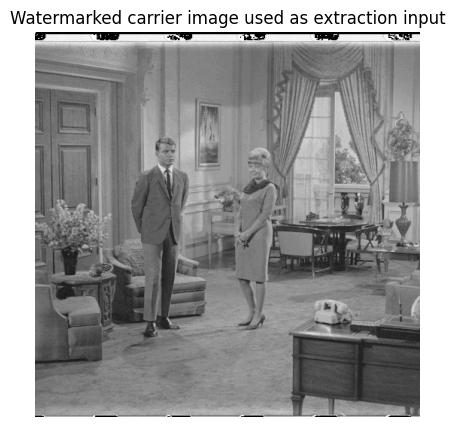

In [3]:
output_directory = Path("example_outputs")
output_directory.mkdir(exist_ok=True)
watermarked_output_path = output_directory / "final_watermarked_output.png"

loader = ImageFileLoader()
dataset = USCSIPISampleDataset(output_directory / "usc_sipi_samples")
sample_paths = dataset.download_default_samples()

original_watermark_image = loader.load_grayscale(sample_paths["watermark_moon_256"])
original_carrier_image = loader.load_grayscale(sample_paths["carrier_couple_512"])

# Regenerate the clean watermarked output from the same implemented embedding path,
# then load the saved image from disk. Extraction below starts from watermarked_image.
embedding_context = EmbeddingPipeline().run(
    watermark_image=original_watermark_image,
    carrier_image=original_carrier_image,
    histogram_denominator_mode="natural",
)
loader.save_png(embedding_context.embedding_result.final_image, watermarked_output_path)
watermarked_image = loader.load_grayscale(watermarked_output_path)

print(f"Watermarked output loaded from: {watermarked_output_path}")
print(f"Watermark size: {len(original_watermark_image)} x {len(original_watermark_image[0])}")
print(f"Watermarked carrier size: {len(watermarked_image)} x {len(watermarked_image[0])}")
show_image(watermarked_image, "Watermarked carrier image used as extraction input", size=5)


## 2. Required Extraction Parameters

The paper's extraction step says the watermarked image is used **along with the required parameters**.

Scale parameters:

| Variable | Meaning |
|---|---|
| `m` | Watermark side exponent, where side length is `2^m`. |
| `n` | Carrier side exponent, where side length is `2^n`. |
| `r = n - m` | Scale factor. This notebook supports the paper-specified `r = 1` path. |
| `beta` | AQSM helper parameter. For `r = 1`, `beta = 2`. |
| `alpha` | Controls low/high block-set counts. For `r = 1`, `alpha = 1`. |
| `d` | QBA aggregation level. For `r = 1`, `d = 1`. |
| `q` | Paper-declared AQSM output count. For `r = 1`, `q = 4`, but only three are embedded/extracted. |

HDWM histogram parameters:

| Variable | Meaning |
|---|---|
| `lambda` | Paper threshold, set to `0.5`. |
| `T_dark` | Fraction of watermark pixels in `0..127`. |
| `T_bright` | Fraction of watermark pixels in `128..255`. |
| `tau1` | HDWM branch selector: balanced vs. strongly biased watermark. |
| `tau2` | HDWM branch selector used only when `tau1 = 1`: dark-biased or bright-biased. |

Extraction cannot infer all of these from the watermarked image alone. The notebook keeps this explicit rather than hiding the dependency.


In [4]:
scale_parameters = ScaleParameterCalculator().compute(
    original_watermark_image,
    watermarked_image,
)
histogram_parameters = HistogramAnalyzer().analyze(
    watermark_image=original_watermark_image,
    scale_parameters=scale_parameters,
    denominator_mode="natural",
)

parameter_table("Scale parameters", scale_parameters.__dict__)
parameter_table("Histogram / HDWM parameters", {
    "dark_count": histogram_parameters.dark_count,
    "bright_count": histogram_parameters.bright_count,
    "denominator": histogram_parameters.denominator,
    "lambda": histogram_parameters.threshold_lambda,
    "T_dark": histogram_parameters.t_dark,
    "T_bright": histogram_parameters.t_bright,
    "tau1": histogram_parameters.tau1,
    "tau2": histogram_parameters.tau2,
})


Scale parameters
  watermark_side_exponent: 8
  carrier_side_exponent: 9
  scale_factor: 1
  beta: 2
  alpha: 1
  aggregation_level: 1
  q_outputs: 4
Histogram / HDWM parameters
  dark_count: 29148
  bright_count: 36388
  denominator: 65536
  lambda: 0.5
  T_dark: 0.44476318359375
  T_bright: 0.55523681640625
  tau1: 0
  tau2: None


## 3. NEQR Representation Of The Watermarked Carrier

The paper says that, before extraction, the classical watermarked image is represented again using NEQR.

In this codebase, `NEQREncoder` creates an inspectable NEQR-like description:

$$
|CW\rangle = \frac{1}{2^n}\sum_Y\sum_X |CW(Y,X)\rangle |YX\rangle
$$

Important implementation note: extraction below operates on the grayscale matrix `watermarked_image`, not on a full quantum statevector. The NEQR object is shown to make the paper's representation visible.


In [5]:
watermarked_neqr = NEQREncoder().encode(watermarked_image)
parameter_table("Watermarked carrier NEQR-like summary", {
    "side exponent n": watermarked_neqr.side_exponent,
    "amplitude": watermarked_neqr.amplitude,
    "basis term count": len(watermarked_neqr.terms),
    "first term": watermarked_neqr.terms[0],
    "second term": watermarked_neqr.terms[1],
})


Watermarked carrier NEQR-like summary
  side exponent n: 9
  amplitude: 0.001953125
  basis term count: 262144
  first term: NEQRPixelTerm(grayscale_bits='11101010', y_bits='000000000', x_bits='000000000')
  second term: NEQRPixelTerm(grayscale_bits='00010100', y_bits='000000000', x_bits='000000001')


## 4. Compute `V_eta` From The Watermarked Carrier

The paper defines:

$$
\eta =
\begin{cases}
0, & r = 1 \\
r \bmod 2, & r > 1
\end{cases}
$$

For the implemented `r = 1` path:

$$
\eta = 0
$$

When `eta = 0`, the paper says HDWM uses the XOR result of 3 MSBs. The implementation uses the natural 8-bit interpretation:

$$
V(Y,X) = c_7(Y,X) \oplus c_6(Y,X) \oplus c_5(Y,X)
$$

`V_eta` is not where the watermark is stored. It is a control/parity bit computed from the carrier MSBs. The watermark payload is extracted from carrier LSB planes `0`, `1`, and `2`.


eta = 0


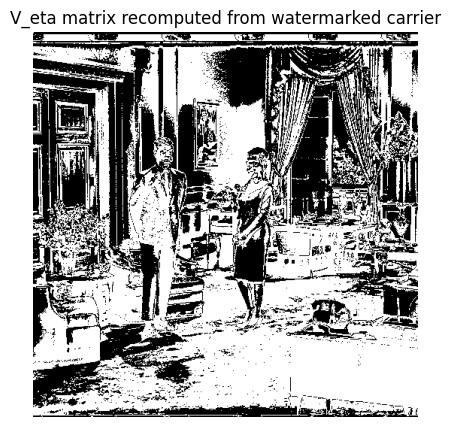

In [6]:
extractor = HDWMExtractor()
eta = extractor.compute_eta(scale_parameters)
xor_matrix = extractor.xor_calculator.compute(watermarked_image, eta)

print(f"eta = {eta}")
show_image(xor_matrix, "V_eta matrix recomputed from watermarked carrier", binary=True, size=5)


## 5. Extract The Three AQSM Watermarks With HDWM Table II

This is the first step where payload bits are actually read out of the watermarked carrier.

For `r = 1`, the paper says to prepare three empty carrier-sized binary images and extract the AQSM watermarks sequentially from the first three LSB planes:

| Extracted AQSM image | Carrier bit plane | Meaning |
|---|---:|---|
| `E1` | bit `0` | Extracted from the first / lowest LSB plane. |
| `E2` | bit `1` | Extracted from the second LSB plane. |
| `E3` | bit `2` | Extracted from the third LSB plane. |

For one watermarked carrier pixel at coordinate `(Y, X)`, write its 8-bit value as:

$$
CW(Y,X) = c_7 c_6 c_5 c_4 c_3 c_2 c_1 c_0
$$

The low bits `c0`, `c1`, and `c2` are the embedded LSB planes. The high bits `c7`, `c6`, and `c5` were used in Step 4 to compute:

$$
V(Y,X) = c_7(Y,X) \oplus c_6(Y,X) \oplus c_5(Y,X)
$$

For extraction, the selected carrier LSB bit is:

$$
L_j(Y,X) = \left(CW(Y,X) \gg (j-1)\right) \& 1
$$

where:

| `j` | selected bit |
|---:|---|
| `1` | `L_1 = c0` |
| `2` | `L_2 = c1` |
| `3` | `L_3 = c2` |

Then HDWM Table II converts that selected LSB bit into the extracted AQSM bit `E_j(Y,X)`.

### Branch 1: `tau1 = 0`

This is the balanced-histogram branch. The selected LSB is already the extracted AQSM bit:

$$
E_j(Y,X) = L_j(Y,X)
$$

So extraction is direct reading from the LSB plane.

### Branch 2: `tau1 = 1`, `tau2 = 0`

This is the strongly dark watermark branch. The extracted bit is decoded using the carrier MSB parity bit:

$$
E_j(Y,X) = L_j(Y,X) \oplus V(Y,X)
$$

### Branch 3: `tau1 = 1`, `tau2 = 1`

This is the strongly bright watermark branch. The extracted bit is decoded using the inverse of the carrier MSB parity bit:

$$
E_j(Y,X) = L_j(Y,X) \oplus (1 - V(Y,X))
$$

### What The Code Does

For every `bit_plane_index` in `0, 1, 2`, the code loops over every watermarked carrier pixel:

```python
carrier_lsb_bit = (watermarked_pixel >> bit_plane_index) & 1
extracted_bit = HDWM_inverse_rule(carrier_lsb_bit, V, tau1, tau2)
```

The result of this loop is one carrier-sized binary image:

```text
bit_plane_index = 0 -> E1
bit_plane_index = 1 -> E2
bit_plane_index = 2 -> E3
```

These `E1`, `E2`, and `E3` images are not yet the final watermark. They are expanded AQSM binary watermark images. The next steps apply inverse QBA and quantum refining to recover the original eight watermark bit planes `w1..w8`.

For the current USC-SIPI sample, the histogram branch is printed above. The code does not hard-code one branch; it uses the computed `tau1` and `tau2`.


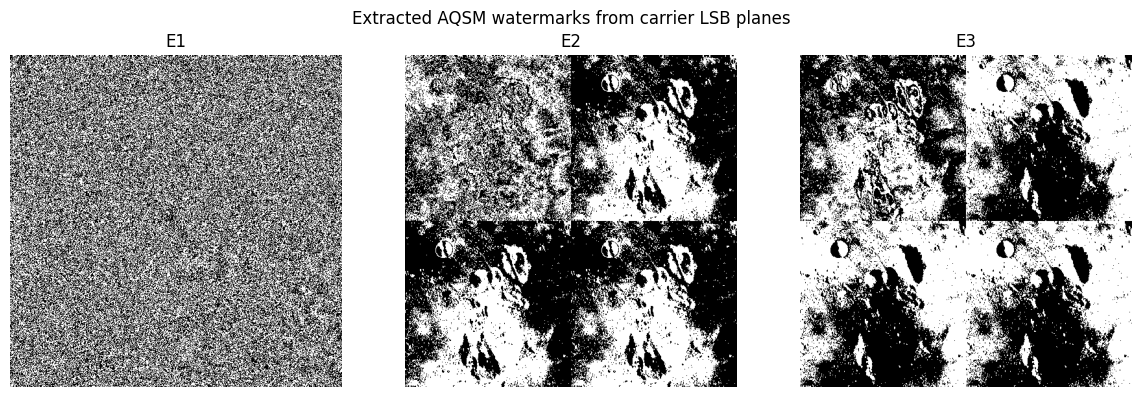

In [7]:
extracted_aqsm_watermarks = [
    extractor.extract_plane(
        watermarked_image=watermarked_image,
        xor_matrix=xor_matrix,
        tau1=histogram_parameters.tau1,
        tau2=histogram_parameters.tau2,
        bit_plane_index=bit_plane_index,
    )
    for bit_plane_index in range(3)
]

show_grid(
    [(f"E{index}", image) for index, image in enumerate(extracted_aqsm_watermarks, start=1)],
    "Extracted AQSM watermarks from carrier LSB planes",
    binary=True,
    columns=3,
    size=4,
)


## 6. Apply Inverse QBA

For `r = 1`, the paper explicitly states the three embedded AQSM block sets:

$$
E_1 = QBA(w_1, w_2, w_3, w_4)
$$

$$
E_2 = QBA(w_5, w_7, w_7, w_7)
$$

$$
E_3 = QBA(w_6, w_8, w_8, w_8)
$$

Inverse QBA splits each carrier-sized extracted AQSM image into four watermark-sized quadrant blocks:

- top-left
- top-right
- bottom-left
- bottom-right

The block mapping is therefore:

| Extracted image | top-left | top-right | bottom-left | bottom-right |
|---|---|---|---|---|
| `E1` | `w1` | `w2` | `w3` | `w4` |
| `E2` | `w5` | `w7` candidate | `w7` candidate | `w7` candidate |
| `E3` | `w6` | `w8` candidate | `w8` candidate | `w8` candidate |


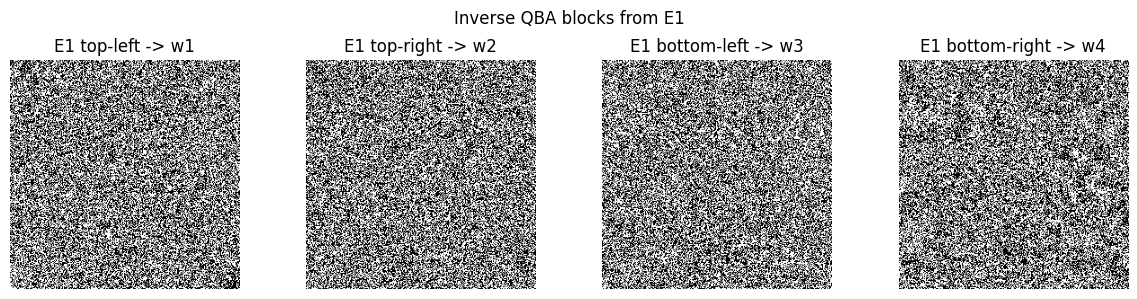

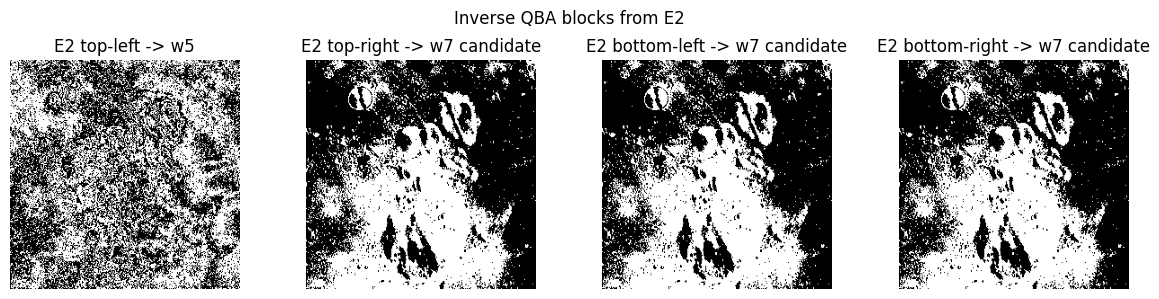

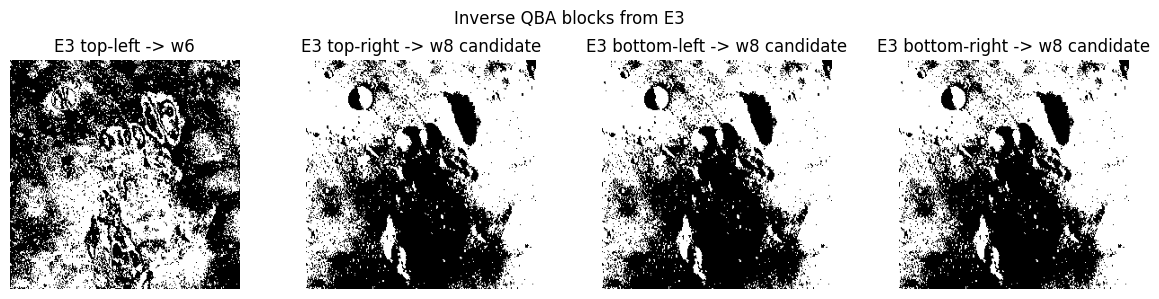

In [8]:
e1_blocks = list(extractor.aggregator.split_four(extracted_aqsm_watermarks[0]))
e2_blocks = list(extractor.aggregator.split_four(extracted_aqsm_watermarks[1]))
e3_blocks = list(extractor.aggregator.split_four(extracted_aqsm_watermarks[2]))

show_grid(
    [("E1 top-left -> w1", e1_blocks[0]), ("E1 top-right -> w2", e1_blocks[1]),
     ("E1 bottom-left -> w3", e1_blocks[2]), ("E1 bottom-right -> w4", e1_blocks[3])],
    "Inverse QBA blocks from E1",
    binary=True,
    columns=4,
    size=3,
)
show_grid(
    [("E2 top-left -> w5", e2_blocks[0]), ("E2 top-right -> w7 candidate", e2_blocks[1]),
     ("E2 bottom-left -> w7 candidate", e2_blocks[2]), ("E2 bottom-right -> w7 candidate", e2_blocks[3])],
    "Inverse QBA blocks from E2",
    binary=True,
    columns=4,
    size=3,
)
show_grid(
    [("E3 top-left -> w6", e3_blocks[0]), ("E3 top-right -> w8 candidate", e3_blocks[1]),
     ("E3 bottom-left -> w8 candidate", e3_blocks[2]), ("E3 bottom-right -> w8 candidate", e3_blocks[3])],
    "Inverse QBA blocks from E3",
    binary=True,
    columns=4,
    size=3,
)


## 7. Apply Quantum Refining As Majority Voting

The paper's quantum refining step extracts logical information from an odd sequence of qubits by keeping the majority and ignoring the minority.

In the implemented matrix simulation, that is pixel-wise majority voting.

For three candidate bit matrices `A`, `B`, and `C`:

$$
majority(A,B,C)[Y,X] =
\begin{cases}
1, & A[Y,X] + B[Y,X] + C[Y,X] \ge 2 \\
0, & \text{otherwise}
\end{cases}
$$

For the `r = 1` mapping:

- `w1`, `w2`, `w3`, `w4`, `w5`, and `w6` are recovered directly from inverse-QBA blocks.
- `w7` is recovered by majority vote over three repeated candidates from `E2`.
- `w8` is recovered by majority vote over three repeated candidates from `E3`.


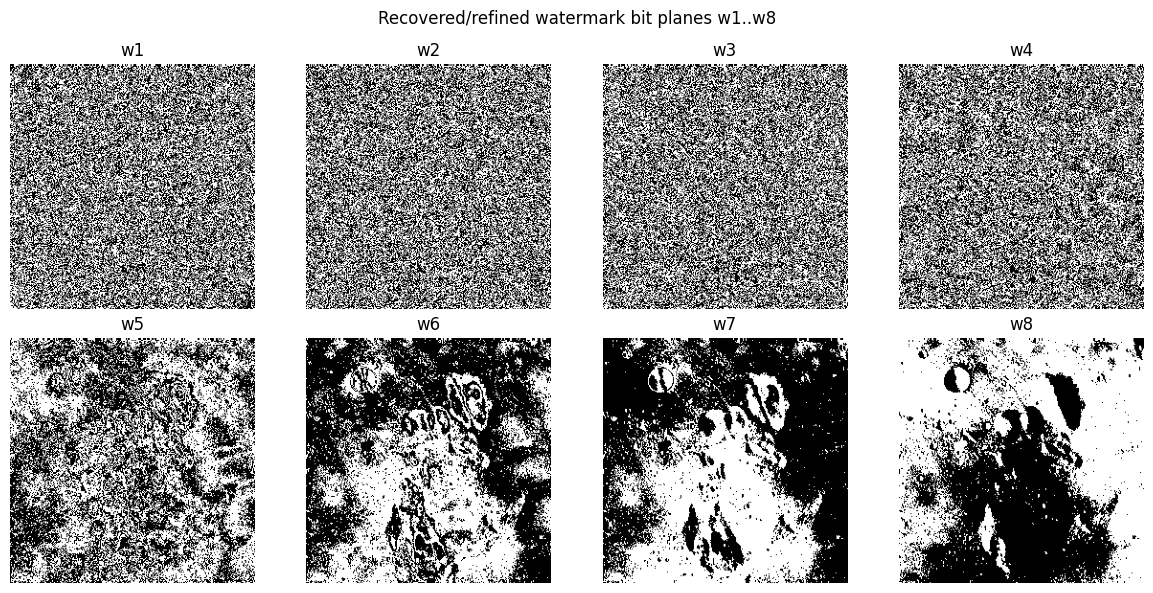

In [9]:
recovered_bit_planes = {
    "w1": e1_blocks[0],
    "w2": e1_blocks[1],
    "w3": e1_blocks[2],
    "w4": e1_blocks[3],
    "w5": e2_blocks[0],
    "w6": e3_blocks[0],
    "w7": extractor.refiner.majority(e2_blocks[1:4]),
    "w8": extractor.refiner.majority(e3_blocks[1:4]),
}

show_grid(
    [(name, recovered_bit_planes[name]) for name in sorted(recovered_bit_planes, key=lambda item: int(item[1:]))],
    "Recovered/refined watermark bit planes w1..w8",
    binary=True,
    columns=4,
    size=3,
)


## 8. Reconstruct The Grayscale Watermark

The final extraction step reconstructs the 8-bit grayscale watermark from the recovered bit planes.

The paper's bit-plane reconstruction corresponds to:

$$
W_{rec}(Y,X) = 1\cdot w_1(Y,X) + 2\cdot w_2(Y,X) + 4\cdot w_3(Y,X) + 8\cdot w_4(Y,X)
$$

$$
+ 16\cdot w_5(Y,X) + 32\cdot w_6(Y,X) + 64\cdot w_7(Y,X) + 128\cdot w_8(Y,X)
$$

Because `w1` is the least significant bit and `w8` is the most significant bit, this recreates the original 8-bit grayscale value at each watermark coordinate.


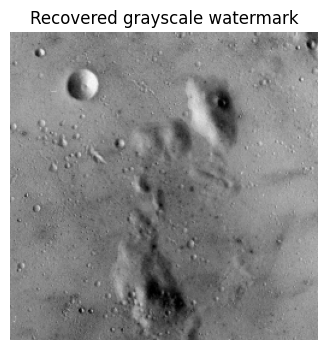

Saved recovered watermark to: example_outputs\recovered_watermark_from_extraction.png


In [10]:
recovered_watermark = extractor.reconstructor.reconstruct(recovered_bit_planes)
recovered_watermark_path = loader.save_png(
    recovered_watermark,
    output_directory / "recovered_watermark_from_extraction.png",
)

show_image(recovered_watermark, "Recovered grayscale watermark", size=4)
print(f"Saved recovered watermark to: {recovered_watermark_path}")


## 9. Run The Same Extraction As One Pipeline Call

The previous sections call each component step by step for clarity. The same implemented algorithm is also available as one call:

```python
extraction_result = HDWMExtractor().extract(...)
```

This returns:

- `xor_matrix`
- `extracted_aqsm_watermarks`
- `inverse_qba_blocks`
- `refined_bit_planes`
- `recovered_watermark`


In [11]:
extraction_result = extractor.extract(
    watermarked_image=watermarked_image,
    histogram_parameters=histogram_parameters,
    scale_parameters=scale_parameters,
)

print("One-call extraction recovered the same watermark:", extraction_result.recovered_watermark == recovered_watermark)


One-call extraction recovered the same watermark: True


## 10. Verify Against The Known Watermark

This verification step is not part of blind extraction. It is here because this notebook is a controlled demo and we know the original watermark image.

For the clean, unattacked watermarked carrier image, the recovered watermark should match the original watermark exactly.


Exact recovered watermark match: True
Maximum absolute pixel difference: 0


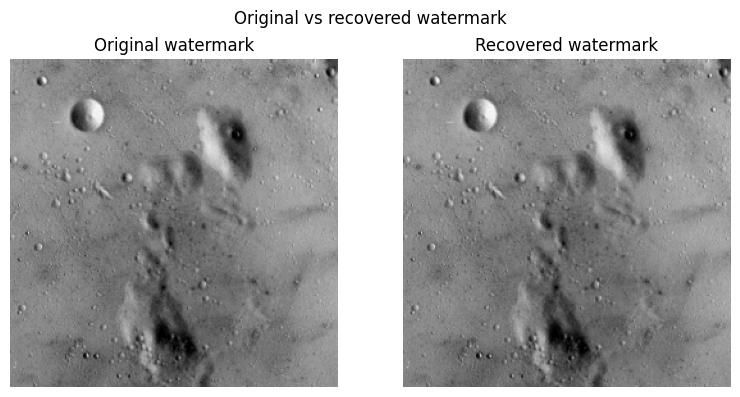

In [12]:
differences = [
    [abs(original - recovered) for original, recovered in zip(original_row, recovered_row)]
    for original_row, recovered_row in zip(original_watermark_image, recovered_watermark)
]
max_difference = max(max(row) for row in differences)
exact_match = recovered_watermark == original_watermark_image

print(f"Exact recovered watermark match: {exact_match}")
print(f"Maximum absolute pixel difference: {max_difference}")

show_grid(
    [("Original watermark", original_watermark_image), ("Recovered watermark", recovered_watermark)],
    "Original vs recovered watermark",
    binary=False,
    columns=2,
    size=4,
)
